# PINN vs FDM: 1D Heat Equation\n
This notebook runs training and visual comparison for the 1D heat equation.

In [1]:
import sys
from pathlib import Path
import importlib

project_root = Path.cwd().parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import train
import visualization

importlib.reload(train)
importlib.reload(visualization)

from train import TrainingConfig, export_artifacts, high_accuracy_config, train_and_compare
from visualization import plot_heatmap, plot_loss_history, plot_time_slices

In [2]:
config = high_accuracy_config()
artifacts = train_and_compare(config)
artifacts.metrics

Epoch     1/3000 total=8.3100e-01 pde=2.1524e-03 ic=7.6951e-01 bc=5.9336e-02
Epoch   200/3000 total=3.3008e-01 pde=2.5333e-02 ic=2.3415e-01 bc=7.0601e-02
Epoch   400/3000 total=2.7437e-01 pde=2.1366e-02 ic=1.9133e-01 bc=6.1677e-02
Epoch   600/3000 total=4.3060e-02 pde=1.2701e-02 ic=1.8236e-02 bc=1.2122e-02
Epoch   800/3000 total=9.8849e-03 pde=6.0412e-03 ic=1.6179e-03 bc=2.2259e-03
Epoch  1000/3000 total=3.6738e-03 pde=2.5031e-03 ic=4.7922e-04 bc=6.9145e-04
Epoch  1200/3000 total=1.6561e-03 pde=1.1937e-03 ic=1.4745e-04 bc=3.1493e-04
Epoch  1400/3000 total=9.3696e-04 pde=6.7274e-04 ic=8.3725e-05 bc=1.8050e-04
Epoch  1600/3000 total=6.7090e-04 pde=4.4987e-04 ic=6.5792e-05 bc=1.5523e-04
Epoch  1800/3000 total=5.2153e-04 pde=3.6060e-04 ic=3.8033e-05 bc=1.2290e-04
Epoch  2000/3000 total=4.1982e-04 pde=2.9950e-04 ic=3.0367e-05 bc=8.9949e-05
Epoch  2200/3000 total=3.5448e-04 pde=2.5496e-04 ic=2.7063e-05 bc=7.2455e-05
Epoch  2400/3000 total=2.6257e-04 pde=1.7971e-04 ic=1.9628e-05 bc=6.3236e-05

{'mse_pinn_vs_fdm': 4.697430349500422e-06,
 'l2_pinn_vs_fdm': 0.004663760605783649,
 'mse_pinn_vs_exact': 4.676120337304753e-06,
 'l2_pinn_vs_exact': 0.004653104746905604}

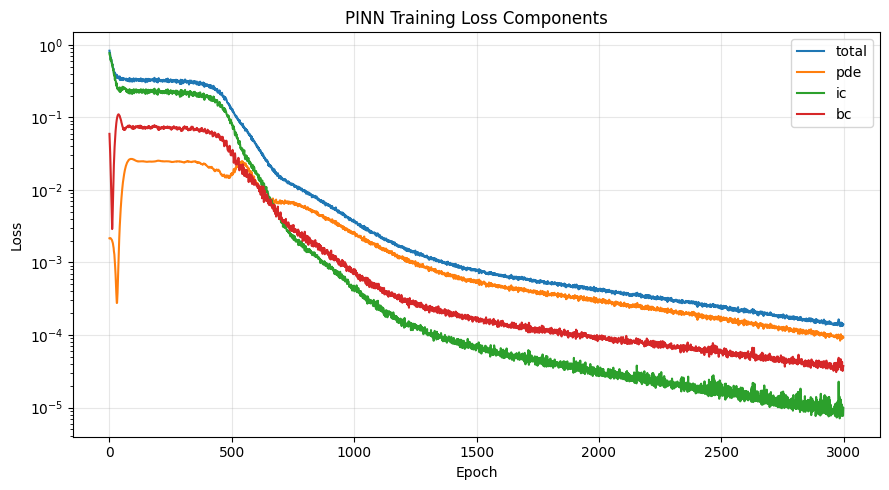

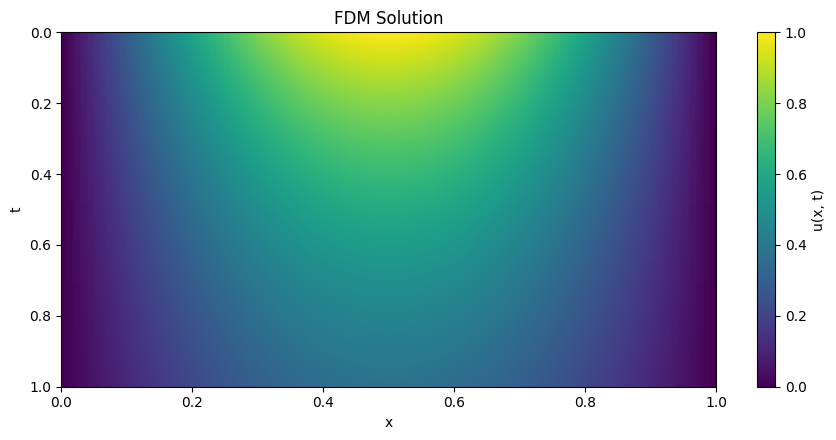

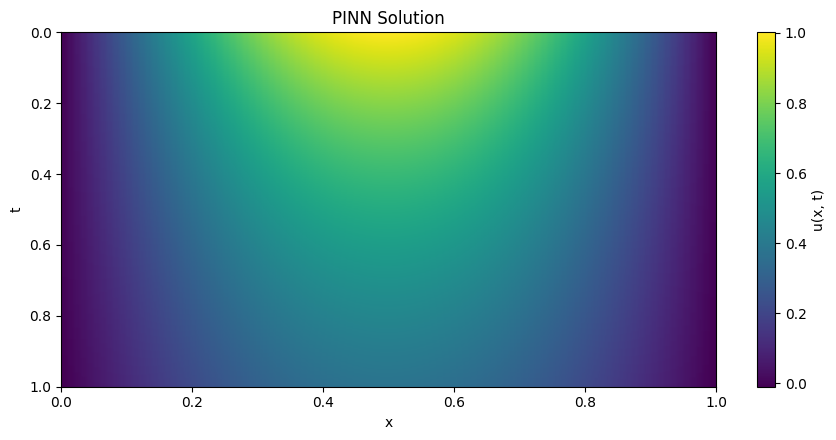

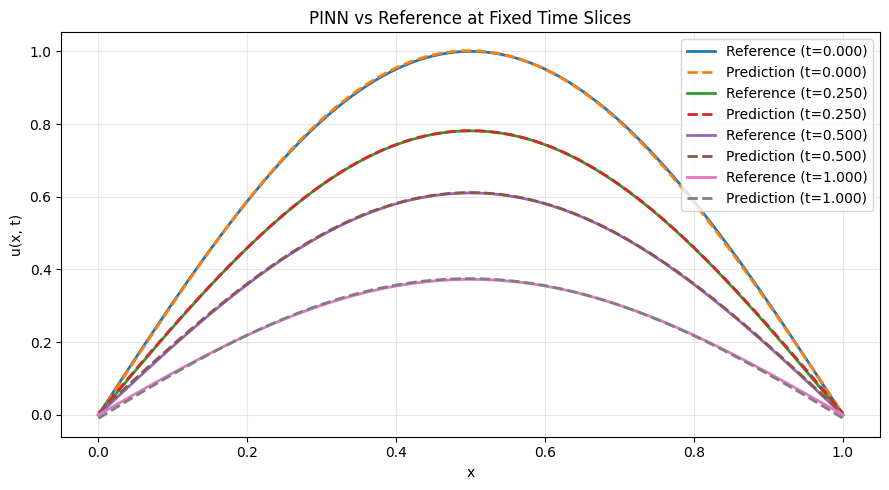

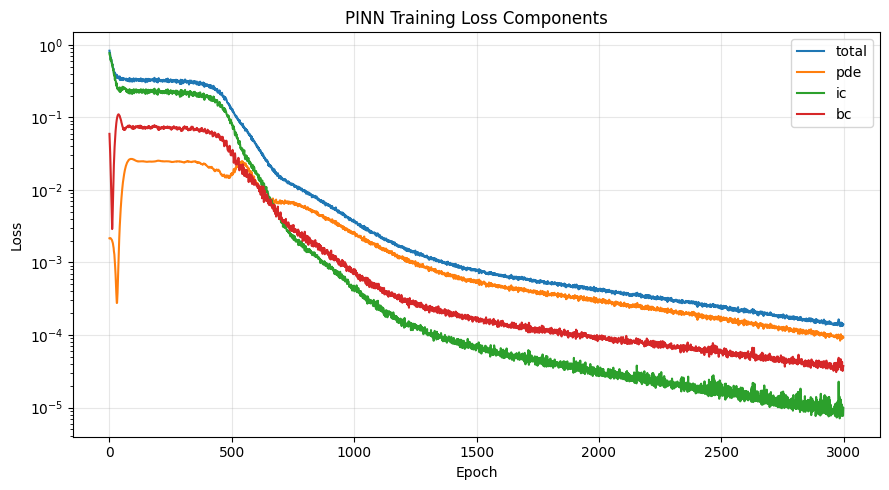

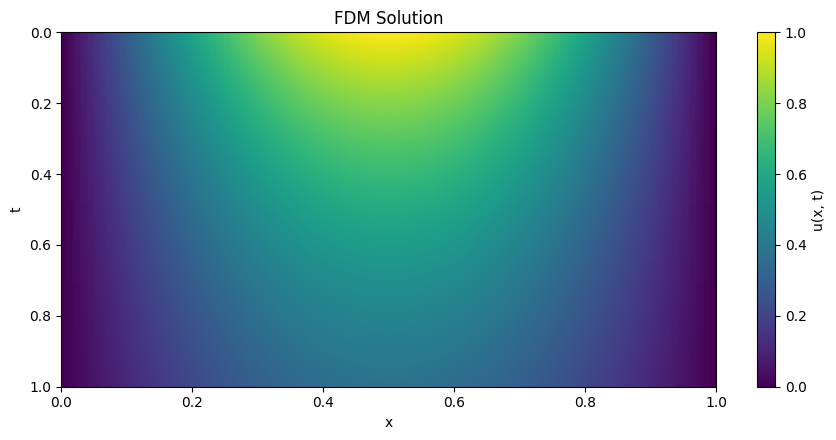

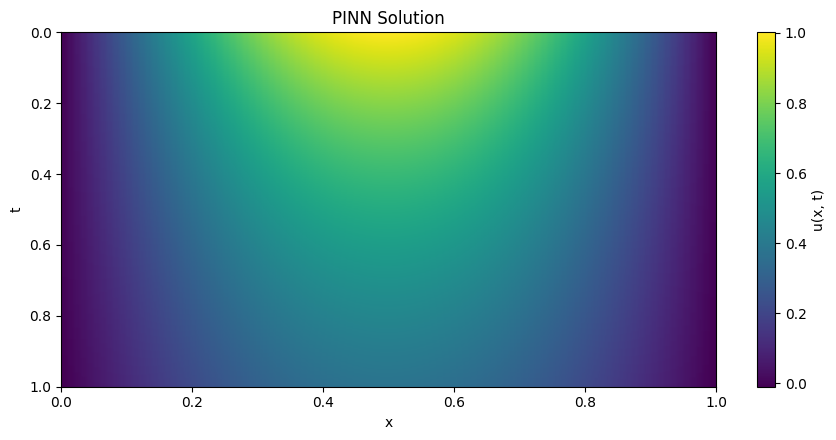

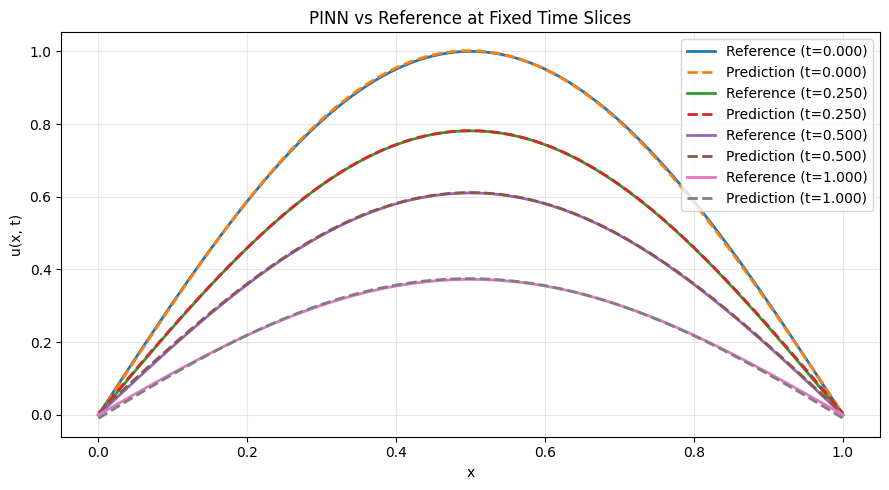

{'metrics_csv': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/metrics.csv'),
 'loss_csv': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/loss_history.csv'),
 'loss_plot': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/loss_history.png'),
 'fdm_heatmap': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/fdm_heatmap.png'),
 'pinn_heatmap': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/pinn_heatmap.png'),
 'comparison_plot': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/comparison_time_slices.png'),
 'model': WindowsPath('c:/Mahindra/learning-differential-physics/outputs/pinn_model.pt')}

In [3]:
plot_loss_history(artifacts.loss_history)
plot_heatmap(artifacts.u_fdm, artifacts.x, artifacts.t, 'FDM Solution')
plot_heatmap(artifacts.u_pinn, artifacts.x, artifacts.t, 'PINN Solution')
plot_time_slices(
    artifacts.x,
    artifacts.t,
    artifacts.u_fdm,
    artifacts.u_pinn,
    time_indices=[0, len(artifacts.t)//4, len(artifacts.t)//2, -1],
)

exported = export_artifacts(artifacts, output_dir=project_root / 'outputs')
exported